In [1]:
# ============================================================
# 0. Imports and unified settings
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

DATA_PATH = Path("df_base.csv")
OUTPUT_DIR = Path("component_feature_selection_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Whole-dataset feature study (not a headline prediction result).
CV_SPLITS = 5
CV_RANDOM_STATE = 42
PI_REPEATS = 5
PI_TOP_N = 25
HOLDOUT_SEEDS = list(range(10))
TEST_SIZE = 0.20  # 20% of the dataset is held out for final evaluation.

# Jsc/Voc retain the established physical-pool compression grid and k.
TOP_K_GRID = [5, 10, 15, 20, 25, 30, 35, 40]
FIXED_SELECTED_K = {"Jsc": 20, "Voc": 20}

# FF is newly screened from the canonical 207-feature all-in space.
FF_TOP_K_GRID = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 207]
FF_SELECTED_K = 30  # Set only after reviewing the FF top-k CV curve.

# Final paired prediction comparison._SIZE = 0.20

# Unified with notebooks 01 and 02.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1
N_JOBS_PI = 1  # Avoid nested parallelism; RF prediction already uses all cores.

MAX_MISSING_RATIO = 0.50
EXPECTED_ALLIN_FEATURES = 207

# FF permutation importance is required for the complete thesis run.
RUN_FF_PERMUTATION_IMPORTANCE = True

TARGETS = {
    "Jsc": "jv.default_Jsc",
    "Voc": "jv.default_Voc",
    "FF": "jv.default_FF",
}
PCE_TARGET = "jv.default_PCE"
REQUIRED_TARGETS = list(TARGETS.values()) + [PCE_TARGET]

print("Whole-dataset CV folds:", CV_SPLITS)
print("Permutation repeats:", PI_REPEATS)
print("Held-out seeds:", HOLDOUT_SEEDS)
print("RF:", N_ESTIMATORS, "trees; min_samples_leaf =", MIN_SAMPLES_LEAF)
print("FF_SELECTED_K:", FF_SELECTED_K)


Whole-dataset CV folds: 5
Permutation repeats: 5
Held-out seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
RF: 200 trees; min_samples_leaf = 1
FF_SELECTED_K: 30


In [2]:
# ============================================================
# 1. Load df_base and reproduce the common 3,953-row analysis set
# ============================================================

def resolve_data_path(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place df_base.csv beside this notebook "
        "or update DATA_PATH."
    )

DATA_PATH = resolve_data_path(DATA_PATH.name)
df_base = pd.read_csv(DATA_PATH, low_memory=False)
# df_base already contains the approved clean thickness, bandgap, and n_layers fields.
# The two agreed Level-3 ratios are calculated below and included in canonical all-in.

missing_targets = [c for c in REQUIRED_TARGETS if c not in df_base.columns]
if missing_targets:
    raise KeyError(f"df_base is missing required targets: {missing_targets}")

for col in REQUIRED_TARGETS:
    df_base[col] = pd.to_numeric(df_base[col], errors="coerce")

def safe_divide(numerator, denominator):
    return (numerator / denominator.replace(0, np.nan)).replace(
        [np.inf, -np.inf], np.nan
    )

# Rebuild the two agreed Level-3 descriptors used downstream and in canonical all-in.
required_thickness = {
    "PVK_thickness_clean", "ETL_thickness_clean",
    "HTL_thickness_clean", "BC_thickness_clean",
}
if required_thickness.issubset(df_base.columns):
    pvk = pd.to_numeric(df_base["PVK_thickness_clean"], errors="coerce")
    etl = pd.to_numeric(df_base["ETL_thickness_clean"], errors="coerce")
    htl = pd.to_numeric(df_base["HTL_thickness_clean"], errors="coerce")
    bc = pd.to_numeric(df_base["BC_thickness_clean"], errors="coerce")
    df_base["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
    df_base["ff_PVK_fraction_of_total_stack"] = safe_divide(
        pvk, pvk + etl + htl + bc
    )

# Match notebook 01 and the 7/8 report: every row has Jsc, Voc, FF, and PCE.
COMMON_TARGET_MASK = df_base[REQUIRED_TARGETS].notna().all(axis=1)
df_model = df_base.loc[COMMON_TARGET_MASK].copy().reset_index(drop=True)
Y = df_model[list(TARGETS.values())].copy().reset_index(drop=True)

print("Loaded:", DATA_PATH)
print("df_base shape:", df_base.shape)
print("Common analysis rows:", len(df_model))
print("Target ranges:")
display(Y.agg(["min", "max", "mean", "std"]).T.round(4))


Loaded: df_base.csv
df_base shape: (3182, 413)
Common analysis rows: 3182
Target ranges:


,min,max,mean,std
jv.default_Jsc,0.011,27.8300,18.6225,4.7422
jv.default_Voc,0.014,1.2800,0.9770,0.1435
jv.default_FF,0.300,0.8995,0.6689,0.1048


In [3]:
# ============================================================
# 2. Build the canonical 207-feature all-in representation
# ============================================================

# Columns added during preprocessing. They are excluded from the raw candidate
# pool first; only the explicitly approved clean/helper representations are
# added back below.
PREPROCESSING_ADDED_COLUMNS = {
    "ETL_layers", "ETL_thickness_values", "ETL_n_layers", "ETL_n_thickness", "ETL_valid",
    "HTL_layers", "HTL_thickness_values", "HTL_n_layers", "HTL_n_thickness", "HTL_valid",
    "BC_layers", "BC_thickness_values", "BC_n_layers", "BC_n_thickness", "BC_valid",
    "ETL_thickness_clean", "HTL_thickness_clean", "BC_thickness_clean",
    "PVK_thickness_clean", "PVK_thickness_note", "PVK_valid",
    "all_layer_match", "perovskite_bandgap_clean", "baseline_complete",
}

# Direct targets and quantities derived from measured performance.
DIRECT_OUTCOME_COLUMNS = {
    # Default, forward, and reverse JV outcomes
    "jv.default_PCE", "jv.default_Jsc", "jv.default_Voc", "jv.default_FF",
    "jv.forward_scan_PCE", "jv.forward_scan_Jsc",
    "jv.forward_scan_Voc", "jv.forward_scan_FF",
    "jv.reverse_scan_PCE", "jv.reverse_scan_Jsc",
    "jv.reverse_scan_Voc", "jv.reverse_scan_FF",

    # Other JV results derived from the measured curve
    "jv.forward_scan_Vmp", "jv.forward_scan_Jmp",
    "jv.reverse_scan_Vmp", "jv.reverse_scan_Jmp",
    "jv.forward_scan_series_resistance",
    "jv.forward_scan_shunt_resistance",
    "jv.reverse_scan_series_resistance",
    "jv.reverse_scan_shunt_resistance",
    "jv.hysteresis_index",

    # Stabilised and EQE performance results
    "stabilised.performance_PCE", "stabilised.performance_Jsc",
    "stabilised.performance_Voc", "stabilised.performance_FF",
    "stabilised.performance_Jmp", "stabilised.performance_Vmp",
    "stabilised.performance_procedure_metrics",
    "eqe.integrated_Jsc",

    # Flags inferred from measured PCE trajectories
    "stability.PCE_burn_in_observed",
    "outdoor.PCE_burn_in_observed",
}

# Replace duplicated raw representations one-for-one with clean versions.
RAW_TO_CLEAN_REPLACEMENTS = {
    "perovskite.band_gap": "perovskite_bandgap_clean",
    "perovskite.thickness": "PVK_thickness_clean",
    "etl.thickness": "ETL_thickness_clean",
    "htl.thickness_list": "HTL_thickness_clean",
    "backcontact.thickness_list": "BC_thickness_clean",
}

LEVEL2_HELPERS = [
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]

# 1) Keep df_base columns with <50% NaN missingness.
# 2) Remove preprocessing-added helpers from the raw candidate pool.
# 3) Remove leakage, provenance/identity, and raw-data links.
missing_ratio = df_base.isna().mean()
eligible_raw_features = [
    column
    for column in df_base.columns
    if missing_ratio[column] < MAX_MISSING_RATIO
    and column not in PREPROCESSING_ADDED_COLUMNS
    and column not in DIRECT_OUTCOME_COLUMNS
    and column not in REQUIRED_TARGETS
    and column not in LEVEL3_FEATURES
    and column != "m_def"
    and not column.startswith("ref.")
    and not column.endswith("link_raw_data")
]

# Replace five raw duplicates, then select the approved Level-2 helpers already
# present in df_base and add the two calculated Level-3 descriptors.
ALLIN_FEATURES = [
    RAW_TO_CLEAN_REPLACEMENTS.get(column, column)
    for column in eligible_raw_features
]
ALLIN_FEATURES += LEVEL2_HELPERS + LEVEL3_FEATURES

required_added_features = (
    list(RAW_TO_CLEAN_REPLACEMENTS.values())
    + LEVEL2_HELPERS
    + LEVEL3_FEATURES
)
missing_added_features = [
    column for column in required_added_features
    if column not in df_base.columns
]
if missing_added_features:
    raise ValueError(
        "Missing canonical clean/helper/derived features in df_base: "
        + ", ".join(missing_added_features)
    )

# Fail loudly if the canonical definition changes unexpectedly.
assert len(eligible_raw_features) == 202
assert len(ALLIN_FEATURES) == EXPECTED_ALLIN_FEATURES
assert len(ALLIN_FEATURES) == len(set(ALLIN_FEATURES))
assert set(RAW_TO_CLEAN_REPLACEMENTS).isdisjoint(ALLIN_FEATURES)
assert set(RAW_TO_CLEAN_REPLACEMENTS.values()).issubset(ALLIN_FEATURES)
assert set(LEVEL2_HELPERS).issubset(ALLIN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALLIN_FEATURES)
assert not set(ALLIN_FEATURES).intersection(DIRECT_OUTCOME_COLUMNS)
assert not any(column.startswith("ref.") for column in ALLIN_FEATURES)
assert any(column.startswith("stability.") for column in ALLIN_FEATURES)
assert any(column.startswith("outdoor.") for column in ALLIN_FEATURES)

X_ALLIN = (
    df_model[ALLIN_FEATURES]
    .replace({pd.NA: np.nan})
    .reset_index(drop=True)
)

print("All-in rows:", len(X_ALLIN))
print("Eligible raw descriptors:", len(eligible_raw_features))
print("Canonical all-in features:", X_ALLIN.shape[1])
print("Numeric:", len(X_ALLIN.select_dtypes(include=np.number).columns))
print(
    "Categorical:",
    X_ALLIN.shape[1] - len(X_ALLIN.select_dtypes(include=np.number).columns),
)
print("Level-2 helpers:", LEVEL2_HELPERS)
print("Level-3 features:", LEVEL3_FEATURES)

pd.Series(ALLIN_FEATURES, name="allin_feature").to_csv(
    OUTPUT_DIR / "allin_feature_list.csv", index=False
)


All-in rows: 3182
Eligible raw descriptors: 202
Canonical all-in features: 207
Numeric: 20
Categorical: 187
Level-2 helpers: ['ETL_n_layers', 'HTL_n_layers', 'BC_n_layers']
Level-3 features: ['Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']


In [4]:
# ============================================================
# 3. Target-specific physical candidate pools and frozen FF useful set
# ============================================================

BASE6 = [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "Absorber_to_ETL_ratio",
]

JSC_DEVICE = [
    "cell.architecture", "cell.area_measured", "cell.flexible",
    "cell.semitransparent", "jv.light_intensity", "jv.light_spectra",
    "jv.light_source_type", "jv.light_masked_cell", "jv.scan_speed",
    "jv.test_atmosphere",
]

JSC_PROCESS = [
    "etl.deposition_procedure",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "perovskite_deposition.procedure",
    "perovskite_deposition.synthesis_atmosphere",
    "perovskite_deposition.substrate_temperature",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite_deposition.quenching_induced_crystallisation",
    "htl.deposition_procedure",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
]

JSC_MATERIAL = [
    "cell.architecture", "etl.stack_sequence", "htl.stack_sequence",
    "backcontact.stack_sequence", "perovskite.composition_short_form",
]

VOC_DEVICE = [
    "cell.architecture", "cell.area_measured", "jv.light_intensity",
    "jv.light_spectra", "jv.light_masked_cell", "jv.scan_speed",
    "jv.test_atmosphere",
]

VOC_PROCESS = [
    "etl.deposition_procedure",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "perovskite_deposition.procedure",
    "perovskite_deposition.synthesis_atmosphere",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite_deposition.quenching_induced_crystallisation",
    "perovskite_deposition.quenching_media",
    "perovskite_deposition.solvents",
    "htl.deposition_procedure",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
]

VOC_MATERIAL = [
    "etl.stack_sequence", "htl.stack_sequence", "backcontact.stack_sequence",
    "perovskite.composition_short_form", "perovskite.composition_a_ions",
    "perovskite.composition_b_ions", "perovskite.composition_c_ions",
    "perovskite.composition_leadfree",
]


FF_CANDIDATES = ALLIN_FEATURES.copy()

def unique_keep_order(values):
    return list(dict.fromkeys(values))

def usable_candidate_columns(proposed):
    present = [c for c in unique_keep_order(proposed) if c in df_model.columns]
    usable = [
        c for c in present
        if df_model[c].isna().mean() < MAX_MISSING_RATIO
        and df_model[c].nunique(dropna=True) > 1
    ]
    dropped = [c for c in unique_keep_order(proposed) if c not in usable]
    return usable, dropped

JSC_CANDIDATES, JSC_DROPPED = usable_candidate_columns(
    BASE6 + JSC_DEVICE + JSC_PROCESS + JSC_MATERIAL
)
VOC_CANDIDATES, VOC_DROPPED = usable_candidate_columns(
    BASE6 + VOC_DEVICE + VOC_PROCESS + VOC_MATERIAL
)

CANDIDATE_POOLS = {
    "Jsc": JSC_CANDIDATES,
    "Voc": VOC_CANDIDATES,
}

candidate_audit = pd.DataFrame([
    {
        "target": "Jsc",
        "selection_space": "Physics-guided candidate pool",
        "requested": len(unique_keep_order(BASE6 + JSC_DEVICE + JSC_PROCESS + JSC_MATERIAL)),
        "retained": len(JSC_CANDIDATES),
        "dropped": " | ".join(JSC_DROPPED),
    },
    {
        "target": "Voc",
        "selection_space": "Physics-guided candidate pool",
        "requested": len(unique_keep_order(BASE6 + VOC_DEVICE + VOC_PROCESS + VOC_MATERIAL)),
        "retained": len(VOC_CANDIDATES),
        "dropped": " | ".join(VOC_DROPPED),
    },
    {
        "target": "FF",
        "selection_space": "Canonical all-in",
        "requested": len(FF_CANDIDATES),
        "retained": len(FF_CANDIDATES),
        "dropped": "",
    },
])
display(candidate_audit)

for target, cols in CANDIDATE_POOLS.items():
    if len(cols) < FIXED_SELECTED_K[target]:
        raise ValueError(
            f"{target} has only {len(cols)} usable candidates; cannot freeze top-20."
        )

assert len(FF_CANDIDATES) == EXPECTED_ALLIN_FEATURES


,target,selection_space,requested,retained,dropped
0,Jsc,Physics-guided candidate pool,34,32,jv.light_source_type | jv.scan_speed
1,Voc,Physics-guided candidate pool,36,35,jv.scan_speed
2,FF,Canonical all-in,207,207,


In [5]:
# ============================================================
# 4. Shared preprocessing and Random Forest helpers
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    transformers = []
    if numeric_cols:
        transformers.append((
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="mean"))]),
            numeric_cols,
        ))
    if categorical_cols:
        transformers.append(
            ("categorical",
        Pipeline([
            # SimpleImputer cannot accept a pure bool array.
            # Convert categorical columns to object while preserving NaN.
            ("to_object", FunctionTransformer(
                lambda x: x.astype(object), validate=False
            )),
            ("imputer", SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )),
            ("to_string", FunctionTransformer(
                lambda x: x.astype(str), validate=False
            )),
            ("onehot", make_onehot_encoder()),
        ]),
        categorical_cols)),
            

    preprocessor = ColumnTransformer(transformers, remainder="drop")
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def clean_feature_frame(frame, columns):
    return (
        frame.reindex(columns=list(columns))
        .replace({pd.NA: np.nan})
        .copy()
    )

def fit_and_score_holdout(X_train, y_train, X_test, y_test):
    model = make_rf_pipeline(X_train)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    return {
        "Test_R2": float(r2_score(y_test, prediction)),
        "Test_RMSE": rmse(y_test, prediction),
    }


In [6]:
# ============================================================
# 5. Whole-dataset validation-fold permutation importance
# ============================================================

def cv_permutation_importance_raw_features(
    X,
    y,
    target_name,
    n_splits=CV_SPLITS,
    n_repeats=PI_REPEATS,
    random_state=CV_RANDOM_STATE,
):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    importance_rows = []
    fold_score_rows = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        print(f"{target_name}: permutation fold {fold}/{n_splits}")
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val = y.iloc[val_idx].copy()

        model = make_rf_pipeline(X_train)
        model.fit(X_train, y_train)
        val_prediction = model.predict(X_val)

        fold_score_rows.append({
            "target": target_name,
            "fold": fold,
            "Val_R2": float(r2_score(y_val, val_prediction)),
            "Val_RMSE": rmse(y_val, val_prediction),
        })

        pi = permutation_importance(
            model,
            X_val,
            y_val,
            scoring="r2",
            n_repeats=n_repeats,
            random_state=random_state + fold,
            n_jobs=N_JOBS_PI,
        )

        for feature_idx, feature in enumerate(X.columns):
            importance_rows.append({
                "target": target_name,
                "fold": fold,
                "feature": feature,
                "importance_mean": float(pi.importances_mean[feature_idx]),
                "importance_repeat_std": float(pi.importances_std[feature_idx]),
            })

    fold_importance = pd.DataFrame(importance_rows)
    fold_scores = pd.DataFrame(fold_score_rows)

    summary = (
        fold_importance
        .groupby(["target", "feature"], as_index=False)
        .agg(
            importance_mean=("importance_mean", "mean"),
            importance_fold_std=("importance_mean", "std"),
            importance_min=("importance_mean", "min"),
            importance_max=("importance_mean", "max"),
            mean_repeat_std=("importance_repeat_std", "mean"),
            n_folds=("fold", "nunique"),
        )
        .sort_values(["importance_mean", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )
    summary.insert(1, "rank", np.arange(1, len(summary) + 1))
    return summary, fold_importance, fold_scores

PI_SUMMARIES = {}
PI_FOLD_DETAILS = {}
PI_FOLD_SCORES = {}

pi_feature_spaces = {
    "Jsc": clean_feature_frame(df_model, JSC_CANDIDATES),
    "Voc": clean_feature_frame(df_model, VOC_CANDIDATES),
}
if RUN_FF_PERMUTATION_IMPORTANCE:
    pi_feature_spaces["FF"] = X_ALLIN.copy()

for target_name, X_pi in pi_feature_spaces.items():
    target_col = TARGETS[target_name]
    summary, fold_detail, fold_scores = cv_permutation_importance_raw_features(
        X_pi,
        Y[target_col],
        target_name=target_name,
    )
    PI_SUMMARIES[target_name] = summary
    PI_FOLD_DETAILS[target_name] = fold_detail
    PI_FOLD_SCORES[target_name] = fold_scores

    summary.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_importance.csv",
        index=False,
    )
    fold_detail.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_folds.csv",
        index=False,
    )
    fold_scores.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_fold_scores.csv",
        index=False,
    )

    print(f"\n{target_name}: top permutation features")
    display(summary.head(PI_TOP_N).round(4))


Jsc: permutation fold 1/5
Jsc: permutation fold 2/5
Jsc: permutation fold 3/5
Jsc: permutation fold 4/5
Jsc: permutation fold 5/5

Jsc: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,Jsc,1,perovskite_bandgap_clean,0.6250,0.0389,0.5875,0.6861,0.0409,5
1,Jsc,2,Absorber_to_ETL_ratio,0.1707,0.0128,0.1591,0.1901,0.0235,5
2,Jsc,3,PVK_thickness_clean,0.1016,0.0395,0.0493,0.1587,0.0097,5
3,Jsc,4,perovskite_deposition.quenching_induced_crysta...,0.0563,0.0370,0.0165,0.0967,0.0123,5
4,Jsc,5,HTL_thickness_clean,0.0278,0.0130,0.0173,0.0493,0.0067,5
5,Jsc,6,etl.deposition_procedure,0.0271,0.0222,0.0008,0.0502,0.0047,5
6,Jsc,7,htl.stack_sequence,0.0197,0.0147,-0.0020,0.0386,0.0050,5
7,Jsc,8,perovskite.composition_short_form,0.0187,0.0057,0.0133,0.0275,0.0029,5
8,Jsc,9,cell.area_measured,0.0135,0.0055,0.0067,0.0216,0.0043,5
9,Jsc,10,etl.stack_sequence,0.0122,0.0072,0.0054,0.0215,0.0028,5


Voc: permutation fold 1/5
Voc: permutation fold 2/5
Voc: permutation fold 3/5
Voc: permutation fold 4/5
Voc: permutation fold 5/5

Voc: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,Voc,1,htl.stack_sequence,0.2238,0.0838,0.1194,0.3470,0.0213,5
1,Voc,2,perovskite.composition_b_ions,0.1181,0.0449,0.0765,0.1702,0.0104,5
2,Voc,3,Absorber_to_ETL_ratio,0.1054,0.0298,0.0688,0.1380,0.0154,5
3,Voc,4,perovskite_deposition.solvents,0.0611,0.0153,0.0384,0.0798,0.0089,5
4,Voc,5,perovskite.composition_leadfree,0.0387,0.0148,0.0159,0.0563,0.0058,5
5,Voc,6,perovskite_deposition.quenching_media,0.0356,0.0402,0.0033,0.1044,0.0080,5
6,Voc,7,BC_thickness_clean,0.0307,0.0241,0.0115,0.0643,0.0061,5
7,Voc,8,PVK_thickness_clean,0.0181,0.0108,0.0011,0.0280,0.0054,5
8,Voc,9,perovskite.composition_a_ions,0.0172,0.0217,-0.0058,0.0525,0.0045,5
9,Voc,10,etl.stack_sequence,0.0145,0.0076,0.0033,0.0238,0.0044,5


FF: permutation fold 1/5
FF: permutation fold 2/5
FF: permutation fold 3/5
FF: permutation fold 4/5
FF: permutation fold 5/5

FF: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,FF,1,ff_PVK_fraction_of_total_stack,0.1405,0.0492,0.0971,0.2134,0.0122,5
1,FF,2,htl.stack_sequence,0.0505,0.0116,0.0387,0.0652,0.0070,5
2,FF,3,ETL_thickness_clean,0.0371,0.0112,0.0185,0.0469,0.0090,5
3,FF,4,PVK_thickness_clean,0.0351,0.0148,0.0265,0.0613,0.0042,5
4,FF,5,eqe.measured,0.0286,0.0157,0.0194,0.0565,0.0102,5
5,FF,6,stabilised.performance_measured,0.0241,0.0106,0.0121,0.0380,0.0087,5
6,FF,7,Absorber_to_ETL_ratio,0.0214,0.0178,0.0072,0.0445,0.0049,5
7,FF,8,ETL_n_layers,0.0118,0.0040,0.0084,0.0183,0.0035,5
8,FF,9,cell.stack_sequence,0.0114,0.0105,-0.0036,0.0239,0.0021,5
9,FF,10,cell.area_measured,0.0112,0.0046,0.0058,0.0164,0.0033,5


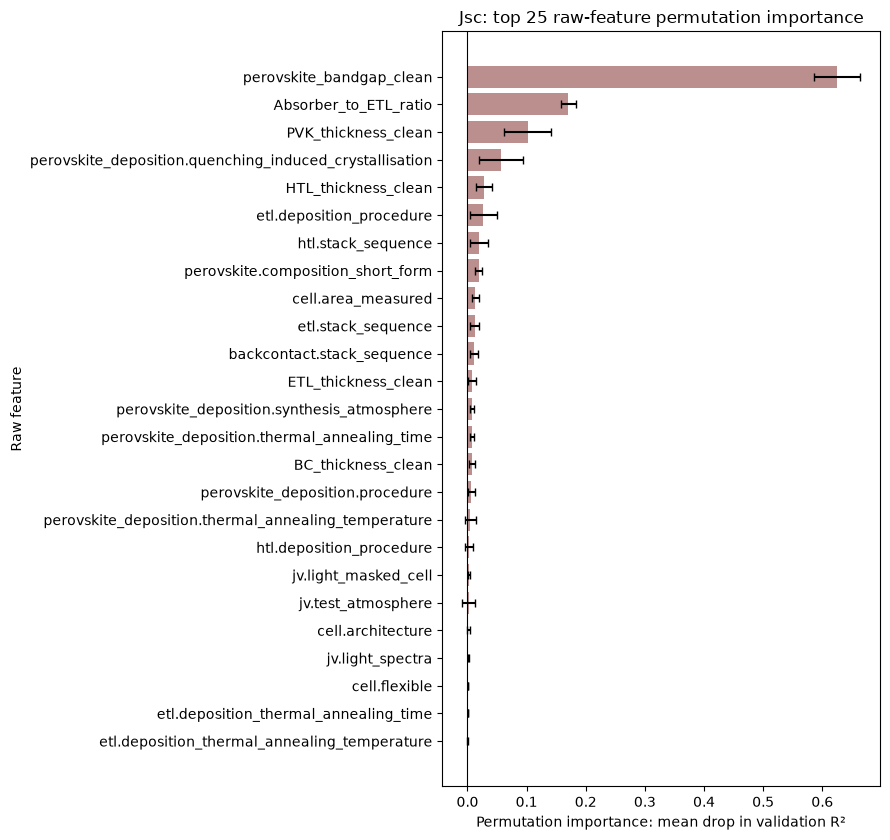

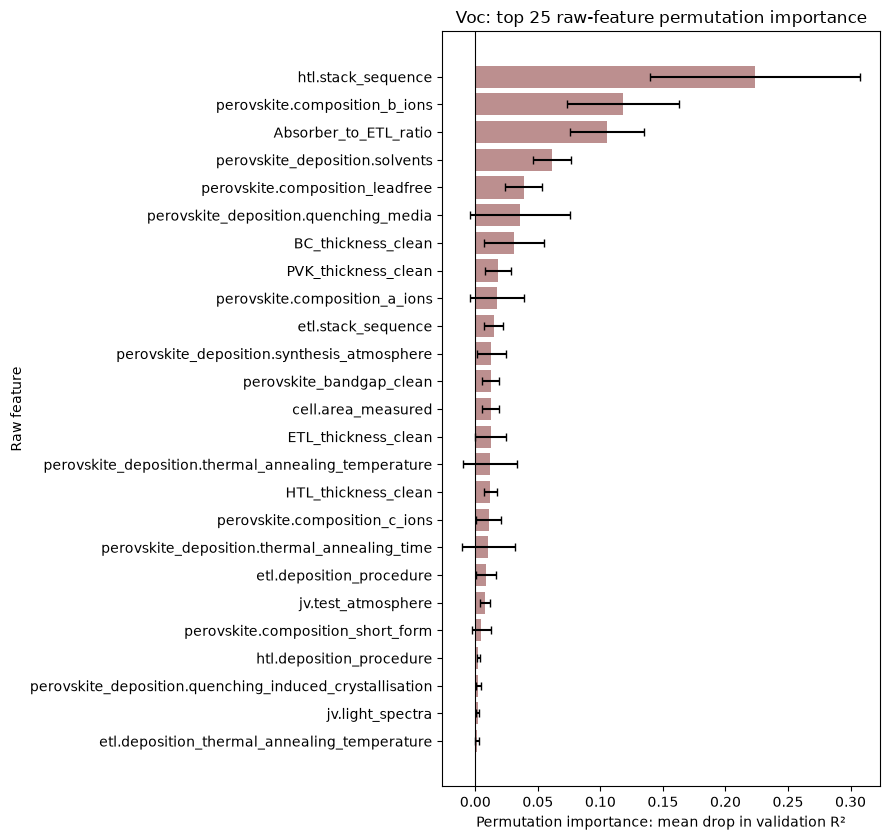

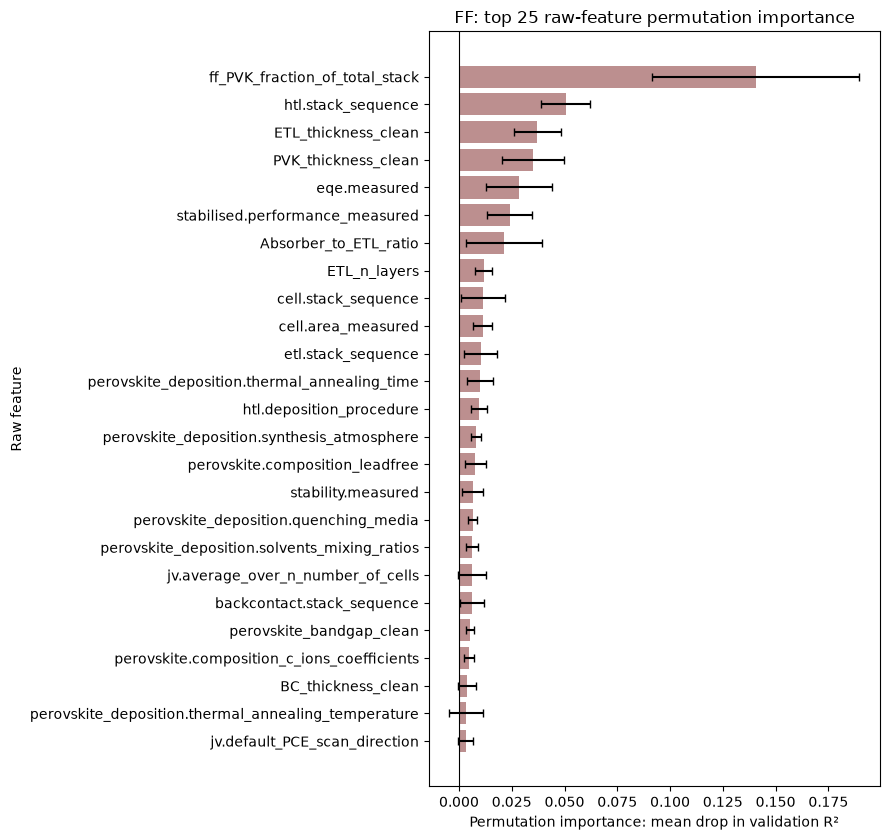

In [7]:
# ============================================================
# 6. Plot whole-dataset CV permutation importance
# ============================================================

for target_name, summary in PI_SUMMARIES.items():
    plot_df = (
        summary.head(PI_TOP_N)
        .sort_values("importance_mean", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, max(5, 0.34 * len(plot_df))))
    ax.barh(
        plot_df["feature"],
        plot_df["importance_mean"],
        xerr=plot_df["importance_fold_std"],
        capsize=3,
        color="rosybrown",
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Permutation importance: mean drop in validation R²")
    ax.set_ylabel("Raw feature")
    ax.set_title(f"{target_name}: top {PI_TOP_N} raw-feature permutation importance")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_importance.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


Jsc: top-5 CV curve
Jsc: top-10 CV curve
Jsc: top-15 CV curve
Jsc: top-20 CV curve
Jsc: top-25 CV curve
Jsc: top-30 CV curve
Jsc: top-32 CV curve


,target,k,CV_R2,CV_RMSE
0,Jsc,5,0.6233,2.9103
1,Jsc,10,0.6661,2.7398
2,Jsc,15,0.6778,2.6914
3,Jsc,20,0.6798,2.6830
4,Jsc,25,0.6801,2.6818
5,Jsc,30,0.6797,2.6832
6,Jsc,32,0.6792,2.6856


Jsc frozen top-20:


,selected_feature
0,perovskite_bandgap_clean
1,Absorber_to_ETL_ratio
2,PVK_thickness_clean
3,perovskite_deposition.quenching_induced_crysta...
4,HTL_thickness_clean
5,etl.deposition_procedure
6,htl.stack_sequence
7,perovskite.composition_short_form
8,cell.area_measured
9,etl.stack_sequence


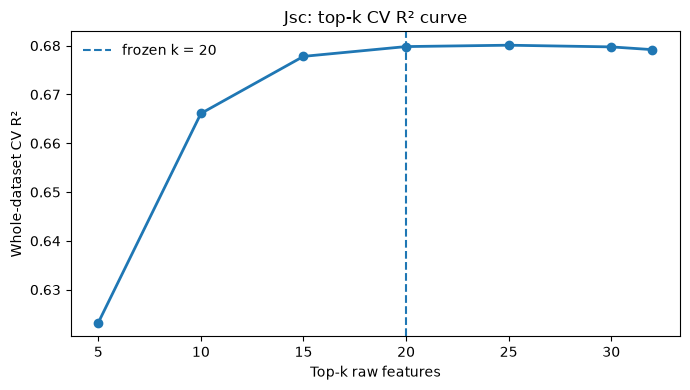

Voc: top-5 CV curve
Voc: top-10 CV curve
Voc: top-15 CV curve
Voc: top-20 CV curve
Voc: top-25 CV curve
Voc: top-30 CV curve
Voc: top-35 CV curve


,target,k,CV_R2,CV_RMSE
0,Voc,5,0.5026,0.1012
1,Voc,10,0.6129,0.0893
2,Voc,15,0.6240,0.0880
3,Voc,20,0.6293,0.0873
4,Voc,25,0.6293,0.0873
5,Voc,30,0.6303,0.0872
6,Voc,35,0.6287,0.0874


Voc frozen top-20:


,selected_feature
0,htl.stack_sequence
1,perovskite.composition_b_ions
2,Absorber_to_ETL_ratio
3,perovskite_deposition.solvents
4,perovskite.composition_leadfree
5,perovskite_deposition.quenching_media
6,BC_thickness_clean
7,PVK_thickness_clean
8,perovskite.composition_a_ions
9,etl.stack_sequence


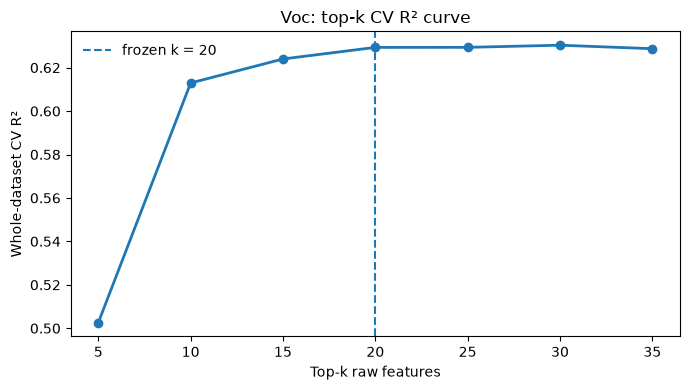

FF: top-5 CV curve
FF: top-10 CV curve
FF: top-15 CV curve
FF: top-20 CV curve
FF: top-25 CV curve
FF: top-30 CV curve
FF: top-40 CV curve
FF: top-50 CV curve
FF: top-75 CV curve
FF: top-100 CV curve
FF: top-150 CV curve
FF: top-207 CV curve


,target,k,CV_R2,CV_RMSE
0,FF,5,0.3997,0.0812
1,FF,10,0.4567,0.0773
2,FF,15,0.4860,0.0751
3,FF,20,0.4946,0.0745
4,FF,25,0.4995,0.0741
5,FF,30,0.5018,0.0740
6,FF,40,0.5030,0.0739
7,FF,50,0.5038,0.0738
8,FF,75,0.5041,0.0738
9,FF,100,0.5034,0.0739


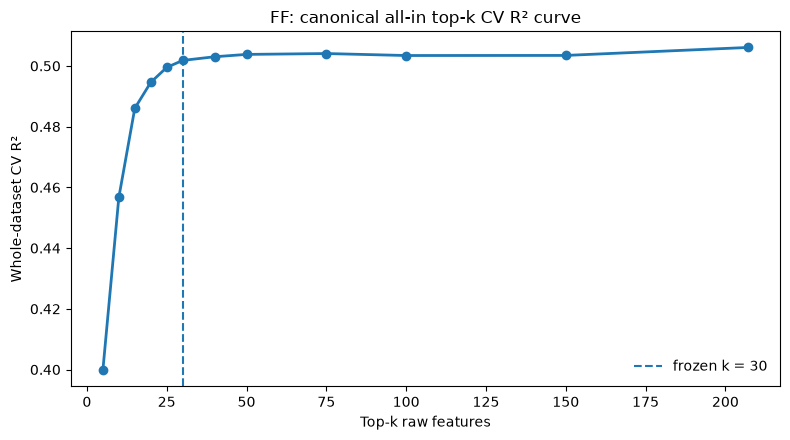

FF frozen top-30:


,selected_feature
0,ff_PVK_fraction_of_total_stack
1,htl.stack_sequence
2,ETL_thickness_clean
3,PVK_thickness_clean
4,eqe.measured
5,stabilised.performance_measured
6,Absorber_to_ETL_ratio
7,ETL_n_layers
8,cell.stack_sequence
9,cell.area_measured


In [8]:
# ============================================================
# 7. Whole-dataset CV top-k curves and fixed selected sets
# ============================================================

def whole_dataset_topk_curve(
    X,
    y,
    ranked_features,
    target_name,
    k_grid,
):
    max_k = len(ranked_features)
    k_values = [k for k in k_grid if k <= max_k]
    k_values = sorted(set(k_values + [max_k]))
    rows = []

    for k in k_values:
        print(f"{target_name}: top-{k} CV curve")
        columns = ranked_features[:k]
        X_k = X[columns].copy()
        cv = KFold(
            n_splits=CV_SPLITS,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )
        model = make_rf_pipeline(X_k)
        prediction = cross_val_predict(
            model,
            X_k,
            y,
            cv=cv,
            n_jobs=1,
        )
        rows.append({
            "target": target_name,
            "k": k,
            "CV_R2": float(r2_score(y, prediction)),
            "CV_RMSE": rmse(y, prediction),
        })
    return pd.DataFrame(rows)

TOPK_CURVES = {}
SELECTED_FEATURES = {}

# Jsc and Voc: unchanged physics-guided selection logic.
for target_name in ["Jsc", "Voc"]:
    ranking = PI_SUMMARIES[target_name]["feature"].tolist()
    X_candidate = clean_feature_frame(df_model, CANDIDATE_POOLS[target_name])
    y_target = Y[TARGETS[target_name]].reset_index(drop=True)

    curve = whole_dataset_topk_curve(
        X_candidate,
        y_target,
        ranking,
        target_name,
        TOP_K_GRID,
    )
    TOPK_CURVES[target_name] = curve
    selected_k = FIXED_SELECTED_K[target_name]
    SELECTED_FEATURES[target_name] = ranking[:selected_k]

    curve.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_whole_dataset_topk_curve.csv",
        index=False,
    )
    pd.Series(
        SELECTED_FEATURES[target_name], name="selected_feature"
    ).to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_selected_top20.csv",
        index=False,
    )

    display(curve.round(4))
    print(f"{target_name} frozen top-{selected_k}:")
    display(pd.DataFrame({"selected_feature": SELECTED_FEATURES[target_name]}))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(curve["k"], curve["CV_R2"], marker="o", linewidth=2)
    ax.axvline(
        selected_k,
        color="tab:blue",
        linestyle="--",
        label=f"frozen k = {selected_k}",
    )
    ax.set_xlabel("Top-k raw features")
    ax.set_ylabel("Whole-dataset CV R²")
    ax.set_title(f"{target_name}: top-k CV R² curve")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{target_name.lower()}_whole_dataset_topk_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

# FF: new selection study from canonical 207-feature all-in.
if "FF" not in PI_SUMMARIES:
    raise RuntimeError(
        "FF permutation importance has not been run. "
        "Set RUN_FF_PERMUTATION_IMPORTANCE=True and run Section 5."
    )

ff_ranking = PI_SUMMARIES["FF"]["feature"].tolist()
ff_curve = whole_dataset_topk_curve(
    X_ALLIN,
    Y[TARGETS["FF"]].reset_index(drop=True),
    ff_ranking,
    "FF",
    FF_TOP_K_GRID,
)
TOPK_CURVES["FF"] = ff_curve
ff_curve.to_csv(
    OUTPUT_DIR / "ff_whole_dataset_topk_curve.csv",
    index=False,
)

display(ff_curve.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ff_curve["k"], ff_curve["CV_R2"], marker="o", linewidth=2)
if FF_SELECTED_K is not None:
    ax.axvline(
        FF_SELECTED_K,
        color="tab:blue",
        linestyle="--",
        label=f"frozen k = {FF_SELECTED_K}",
    )
    ax.legend(frameon=False)
ax.set_xlabel("Top-k raw features")
ax.set_ylabel("Whole-dataset CV R²")
ax.set_title("FF: canonical all-in top-k CV R² curve")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "ff_whole_dataset_topk_curve.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

if FF_SELECTED_K is None:
    print(
        "\nSTOP AFTER REVIEWING THE FF CURVE. "
        "Choose FF_SELECTED_K in the settings cell, then rerun this cell "
        "before running the held-out section."
    )
else:
    if not 1 <= FF_SELECTED_K <= len(ff_ranking):
        raise ValueError(
            f"FF_SELECTED_K must be between 1 and {len(ff_ranking)}."
        )
    SELECTED_FEATURES["FF"] = ff_ranking[:FF_SELECTED_K]
    pd.Series(
        SELECTED_FEATURES["FF"], name="selected_feature"
    ).to_csv(
        OUTPUT_DIR / f"ff_selected_top{FF_SELECTED_K}.csv",
        index=False,
    )
    print(f"FF frozen top-{FF_SELECTED_K}:")
    display(pd.DataFrame({"selected_feature": SELECTED_FEATURES["FF"]}))

selected_features_for_export = {
    "Jsc": SELECTED_FEATURES["Jsc"],
    "Voc": SELECTED_FEATURES["Voc"],
    "FF": SELECTED_FEATURES.get("FF"),
}
with open(OUTPUT_DIR / "selected_features.json", "w", encoding="utf-8") as handle:
    json.dump(selected_features_for_export, handle, indent=2)


In [9]:
# ============================================================
# 8. Paired repeated held-out evaluation
# ============================================================

if FF_SELECTED_K is None or "FF" not in SELECTED_FEATURES:
    raise ValueError(
        "FF selection is not frozen. Review the FF top-k CV curve, set "
        "FF_SELECTED_K in the settings cell, and rerun Section 7 first."
    )

FEATURE_SETS = {
    "Jsc": {
        "Selected 20": SELECTED_FEATURES["Jsc"],
        "All-in": ALLIN_FEATURES,
    },
    "Voc": {
        "Selected 20": SELECTED_FEATURES["Voc"],
        "All-in": ALLIN_FEATURES,
    },
    "FF": {
        f"Selected {FF_SELECTED_K}": SELECTED_FEATURES["FF"],
        "All-in": ALLIN_FEATURES,
    },
}

all_indices = np.arange(len(df_model))
heldout_rows = []

for split_seed in HOLDOUT_SEEDS:
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    for target_name, target_col in TARGETS.items():
        y_train = Y[target_col].iloc[train_idx].reset_index(drop=True)
        y_test = Y[target_col].iloc[test_idx].reset_index(drop=True)

        for feature_set_name, feature_cols in FEATURE_SETS[target_name].items():
            X_target = clean_feature_frame(df_model, feature_cols)
            X_train = X_target.iloc[train_idx].reset_index(drop=True)
            X_test = X_target.iloc[test_idx].reset_index(drop=True)

            scores = fit_and_score_holdout(
                X_train, y_train, X_test, y_test
            )
            heldout_rows.append({
                "target": target_name,
                "target_column": target_col,
                "split_seed": split_seed,
                "feature_set": feature_set_name,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "n_raw_features": len(feature_cols),
                **scores,
            })

            print(
                f"seed={split_seed} | {target_name:>3} | "
                f"{feature_set_name:<11} | R2={scores['Test_R2']:.4f} | "
                f"RMSE={scores['Test_RMSE']:.4f}"
            )

    # Checkpoint after each complete paired split.
    pd.DataFrame(heldout_rows).to_csv(
        OUTPUT_DIR / "component_heldout_results_by_seed_PARTIAL.csv",
        index=False,
    )

COMPONENT_HELDOUT_RESULTS = pd.DataFrame(heldout_rows)
COMPONENT_HELDOUT_RESULTS.to_csv(
    OUTPUT_DIR / "component_heldout_results_by_seed.csv",
    index=False,
)

print("Completed rows:", len(COMPONENT_HELDOUT_RESULTS))


seed=0 | Jsc | Selected 20 | R2=0.6987 | RMSE=2.4536
seed=0 | Jsc | All-in      | R2=0.7060 | RMSE=2.4236
seed=0 | Voc | Selected 20 | R2=0.5510 | RMSE=0.0878
seed=0 | Voc | All-in      | R2=0.5694 | RMSE=0.0860
seed=0 |  FF | Selected 30 | R2=0.4935 | RMSE=0.0780
seed=0 |  FF | All-in      | R2=0.4956 | RMSE=0.0778
seed=1 | Jsc | Selected 20 | R2=0.6675 | RMSE=2.5639
seed=1 | Jsc | All-in      | R2=0.6350 | RMSE=2.6865
seed=1 | Voc | Selected 20 | R2=0.6609 | RMSE=0.0835
seed=1 | Voc | All-in      | R2=0.6587 | RMSE=0.0838
seed=1 |  FF | Selected 30 | R2=0.4390 | RMSE=0.0779
seed=1 |  FF | All-in      | R2=0.4338 | RMSE=0.0783
seed=2 | Jsc | Selected 20 | R2=0.6987 | RMSE=2.6056
seed=2 | Jsc | All-in      | R2=0.6848 | RMSE=2.6650
seed=2 | Voc | Selected 20 | R2=0.6661 | RMSE=0.0833
seed=2 | Voc | All-in      | R2=0.6770 | RMSE=0.0820
seed=2 |  FF | Selected 30 | R2=0.5013 | RMSE=0.0741
seed=2 |  FF | All-in      | R2=0.5147 | RMSE=0.0731
seed=3 | Jsc | Selected 20 | R2=0.6594 | RMSE=

In [10]:
# ============================================================
# 9. Final mean ± std and paired deltas
# ============================================================

COMPONENT_HELDOUT_SUMMARY = (
    COMPONENT_HELDOUT_RESULTS
    .groupby(["target", "feature_set"], as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        n_raw_features=("n_raw_features", "first"),
        Test_R2_mean=("Test_R2", "mean"),
        Test_R2_std=("Test_R2", "std"),
        Test_R2_min=("Test_R2", "min"),
        Test_R2_max=("Test_R2", "max"),
        Test_RMSE_mean=("Test_RMSE", "mean"),
        Test_RMSE_std=("Test_RMSE", "std"),
        Test_RMSE_min=("Test_RMSE", "min"),
        Test_RMSE_max=("Test_RMSE", "max"),
    )
    .sort_values(["target", "feature_set"])
    .reset_index(drop=True)
)

display(COMPONENT_HELDOUT_SUMMARY.round(4))
COMPONENT_HELDOUT_SUMMARY.to_csv(
    OUTPUT_DIR / "component_heldout_summary.csv", index=False
)

allin_rows = (
    COMPONENT_HELDOUT_RESULTS.loc[
        COMPONENT_HELDOUT_RESULTS["feature_set"] == "All-in",
        ["target", "split_seed", "Test_R2", "Test_RMSE"],
    ]
    .rename(columns={
        "Test_R2": "Test_R2_Allin",
        "Test_RMSE": "Test_RMSE_Allin",
    })
)
selected_rows = (
    COMPONENT_HELDOUT_RESULTS.loc[
        COMPONENT_HELDOUT_RESULTS["feature_set"] != "All-in",
        ["target", "split_seed", "feature_set", "Test_R2", "Test_RMSE"],
    ]
    .rename(columns={
        "Test_R2": "Test_R2_Selected",
        "Test_RMSE": "Test_RMSE_Selected",
    })
)
paired = selected_rows.merge(
    allin_rows,
    on=["target", "split_seed"],
    how="inner",
    validate="one_to_one",
)
paired["Delta_R2_Selected_minus_Allin"] = (
    paired["Test_R2_Selected"] - paired["Test_R2_Allin"]
)
paired["Delta_RMSE_Selected_minus_Allin"] = (
    paired["Test_RMSE_Selected"] - paired["Test_RMSE_Allin"]
)

COMPONENT_PAIRED_SUMMARY = (
    paired
    .groupby("target", as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        Delta_R2_mean=("Delta_R2_Selected_minus_Allin", "mean"),
        Delta_R2_std=("Delta_R2_Selected_minus_Allin", "std"),
        Delta_RMSE_mean=("Delta_RMSE_Selected_minus_Allin", "mean"),
        Delta_RMSE_std=("Delta_RMSE_Selected_minus_Allin", "std"),
        selected_wins_R2=(
            "Delta_R2_Selected_minus_Allin", lambda values: int((values > 0).sum())
        ),
    )
)

display(COMPONENT_PAIRED_SUMMARY.round(4))
paired.to_csv(OUTPUT_DIR / "component_paired_results_by_seed.csv", index=False)
COMPONENT_PAIRED_SUMMARY.to_csv(
    OUTPUT_DIR / "component_paired_summary.csv", index=False
)


,target,feature_set,n_splits,n_raw_features,Test_R2_mean,Test_R2_std,Test_R2_min,Test_R2_max,Test_RMSE_mean,Test_RMSE_std,Test_RMSE_min,Test_RMSE_max
0,FF,All-in,10,207,0.4927,0.0357,0.4293,0.5314,0.0743,0.0031,0.0695,0.0791
1,FF,Selected 30,10,30,0.4902,0.0339,0.4273,0.5299,0.0745,0.0030,0.0696,0.0792
2,Jsc,All-in,10,207,0.6909,0.0434,0.6345,0.7640,2.5644,0.1365,2.3291,2.7553
3,Jsc,Selected 20,10,20,0.6945,0.0403,0.6325,0.7554,2.5500,0.1222,2.3712,2.7390
4,Voc,All-in,10,207,0.6440,0.0579,0.5442,0.7028,0.0829,0.0083,0.0699,0.0979
5,Voc,Selected 20,10,20,0.6389,0.0599,0.5510,0.7052,0.0835,0.0084,0.0691,0.0969


,target,n_splits,Delta_R2_mean,Delta_R2_std,Delta_RMSE_mean,Delta_RMSE_std,selected_wins_R2
0,FF,10,-0.0024,0.0052,0.0002,0.0004,3
1,Jsc,10,0.0037,0.0139,-0.0144,0.0553,5
2,Voc,10,-0.0051,0.0129,0.0006,0.0014,5


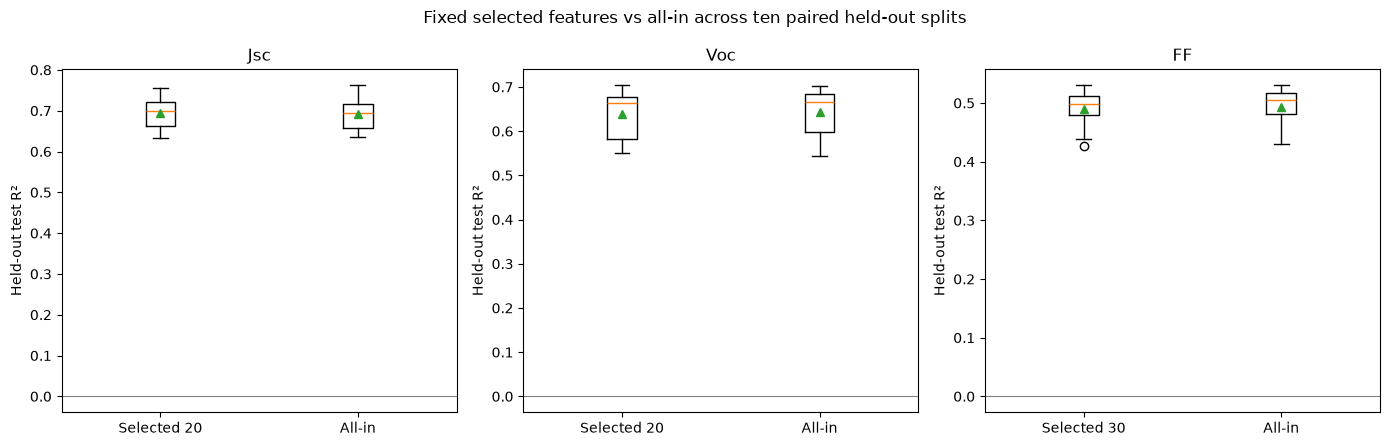

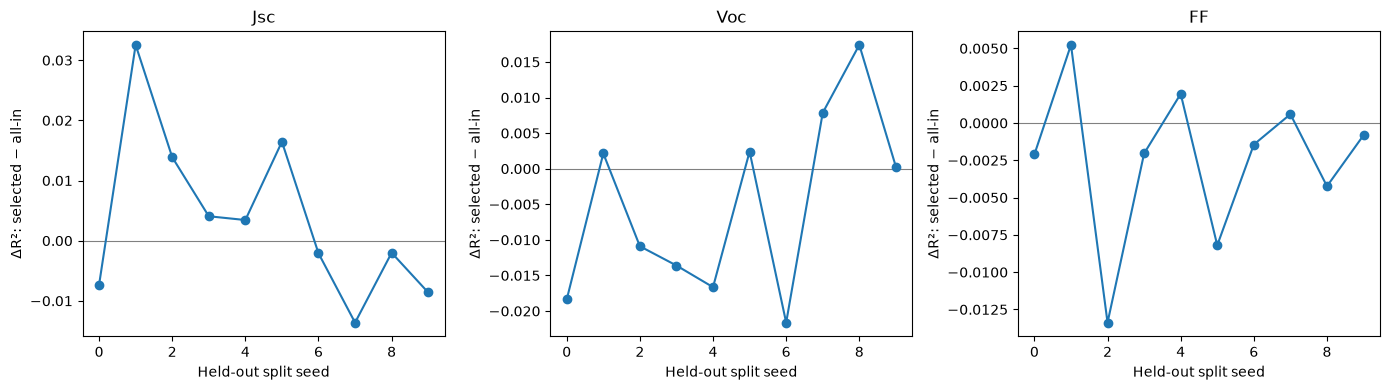

In [11]:
# ============================================================
# 10. Thesis-facing held-out comparison figures
# ============================================================

target_order = ["Jsc", "Voc", "FF"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, target_name in zip(axes, target_order):
    selected_label = f"Selected {FF_SELECTED_K}" if target_name == "FF" else "Selected 20"
    feature_order = [selected_label, "All-in"]
    plot_data = [
        COMPONENT_HELDOUT_RESULTS.loc[
            (COMPONENT_HELDOUT_RESULTS["target"] == target_name)
            & (COMPONENT_HELDOUT_RESULTS["feature_set"] == feature_set),
            "Test_R2",
        ].values
        for feature_set in feature_order
    ]
    ax.boxplot(plot_data, tick_labels=feature_order, showmeans=True)
    ax.set_title(target_name)
    ax.set_ylabel("Held-out test R²")
    ax.axhline(0, color="grey", linewidth=0.8)

fig.suptitle("Fixed selected features vs all-in across ten paired held-out splits")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "component_selected_vs_allin_heldout_r2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Direct paired difference by seed for all three component targets.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, target_name in zip(axes, target_order):
    target_pair = paired[paired["target"] == target_name].sort_values("split_seed")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.plot(
        target_pair["split_seed"],
        target_pair["Delta_R2_Selected_minus_Allin"],
        marker="o",
    )
    ax.set_title(target_name)
    ax.set_xlabel("Held-out split seed")
    ax.set_ylabel("ΔR²: selected − all-in")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "component_paired_delta_r2_by_seed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [12]:

# ============================================================
# 11. Train-only feature-reselection sensitivity audit
# ============================================================

RUN_TRAIN_ONLY_RESELECTION_AUDIT = True
RESELECTION_SEEDS = HOLDOUT_SEEDS
RESELECTION_PI_REPEATS = PI_REPEATS

RESELECTION_OUTPUT_DIR = OUTPUT_DIR / "train_only_reselection_audit"
RESELECTION_OUTPUT_DIR.mkdir(exist_ok=True)

AUDIT_CANDIDATE_POOLS = {
    "Jsc": JSC_CANDIDATES,
    "Voc": VOC_CANDIDATES,
    "FF": ALLIN_FEATURES,
}
AUDIT_SELECTED_K = {
    "Jsc": FIXED_SELECTED_K["Jsc"],
    "Voc": FIXED_SELECTED_K["Voc"],
    "FF": FF_SELECTED_K,
}

if RUN_TRAIN_ONLY_RESELECTION_AUDIT:
    if FF_SELECTED_K is None:
        raise ValueError("FF_SELECTED_K must be fixed before running the audit.")
    if "COMPONENT_HELDOUT_RESULTS" not in globals():
        raise RuntimeError(
            "Run the original paired held-out evaluation (Section 8) before "
            "the train-only reselection audit."
        )

    audit_result_rows = []
    audit_feature_rows = []
    all_indices = np.arange(len(df_model))

    for split_seed in RESELECTION_SEEDS:
        outer_train_idx, outer_test_idx = train_test_split(
            all_indices,
            test_size=TEST_SIZE,
            random_state=split_seed,
            shuffle=True,
        )

        outer_train_df = df_model.iloc[outer_train_idx].reset_index(drop=True)
        outer_test_df = df_model.iloc[outer_test_idx].reset_index(drop=True)

        print("\n" + "=" * 72)
        print(f"Outer split seed {split_seed}: train={len(outer_train_idx)}, test={len(outer_test_idx)}")

        for target_name, target_col in TARGETS.items():
            candidate_cols = AUDIT_CANDIDATE_POOLS[target_name]
            selected_k = AUDIT_SELECTED_K[target_name]

            X_rank_train = clean_feature_frame(outer_train_df, candidate_cols)
            y_outer_train = outer_train_df[target_col].reset_index(drop=True)
            y_outer_test = outer_test_df[target_col].reset_index(drop=True)

            ranking_summary, _, ranking_fold_scores = cv_permutation_importance_raw_features(
                X_rank_train,
                y_outer_train,
                target_name=f"{target_name} outer-seed-{split_seed}",
                n_splits=CV_SPLITS,
                n_repeats=RESELECTION_PI_REPEATS,
                random_state=CV_RANDOM_STATE + 1000 * split_seed,
            )

            train_only_selected = ranking_summary["feature"].head(selected_k).tolist()
            if len(train_only_selected) != selected_k:
                raise RuntimeError(
                    f"{target_name}, seed {split_seed}: expected {selected_k} "
                    f"selected features, got {len(train_only_selected)}."
                )

            # Fit a completely new outer model using only the train-selected columns.
            X_outer_train = clean_feature_frame(outer_train_df, train_only_selected)
            X_outer_test = clean_feature_frame(outer_test_df, train_only_selected)
            train_only_scores = fit_and_score_holdout(
                X_outer_train,
                y_outer_train,
                X_outer_test,
                y_outer_test,
            )

            frozen_label = (
                f"Selected {FF_SELECTED_K}" if target_name == "FF" else "Selected 20"
            )
            frozen_match = COMPONENT_HELDOUT_RESULTS.loc[
                (COMPONENT_HELDOUT_RESULTS["target"] == target_name)
                & (COMPONENT_HELDOUT_RESULTS["split_seed"] == split_seed)
                & (COMPONENT_HELDOUT_RESULTS["feature_set"] == frozen_label)
            ]
            allin_match = COMPONENT_HELDOUT_RESULTS.loc[
                (COMPONENT_HELDOUT_RESULTS["target"] == target_name)
                & (COMPONENT_HELDOUT_RESULTS["split_seed"] == split_seed)
                & (COMPONENT_HELDOUT_RESULTS["feature_set"] == "All-in")
            ]
            if len(frozen_match) != 1 or len(allin_match) != 1:
                raise RuntimeError(
                    f"Could not find unique frozen/all-in results for "
                    f"{target_name}, seed {split_seed}."
                )

            frozen_row = frozen_match.iloc[0]
            allin_row = allin_match.iloc[0]
            frozen_features = SELECTED_FEATURES[target_name]
            frozen_set = set(frozen_features)
            train_only_set = set(train_only_selected)
            overlap = len(frozen_set & train_only_set)
            union_size = len(frozen_set | train_only_set)
            jaccard = overlap / union_size if union_size else np.nan

            audit_result_rows.append({
                "target": target_name,
                "split_seed": split_seed,
                "n_train": len(outer_train_idx),
                "n_test": len(outer_test_idx),
                "candidate_pool_size": len(candidate_cols),
                "selected_k": selected_k,
                "TrainOnly_R2": train_only_scores["Test_R2"],
                "TrainOnly_RMSE": train_only_scores["Test_RMSE"],
                "Frozen_R2": float(frozen_row["Test_R2"]),
                "Frozen_RMSE": float(frozen_row["Test_RMSE"]),
                "Allin_R2": float(allin_row["Test_R2"]),
                "Allin_RMSE": float(allin_row["Test_RMSE"]),
                "Delta_R2_TrainOnly_minus_Frozen": (
                    train_only_scores["Test_R2"] - float(frozen_row["Test_R2"])
                ),
                "Delta_RMSE_TrainOnly_minus_Frozen": (
                    train_only_scores["Test_RMSE"] - float(frozen_row["Test_RMSE"])
                ),
                "Delta_R2_TrainOnly_minus_Allin": (
                    train_only_scores["Test_R2"] - float(allin_row["Test_R2"])
                ),
                "Delta_RMSE_TrainOnly_minus_Allin": (
                    train_only_scores["Test_RMSE"] - float(allin_row["Test_RMSE"])
                ),
                "overlap_with_frozen": overlap,
                "jaccard_with_frozen": jaccard,
                "inner_PI_R2_mean": float(ranking_fold_scores["Val_R2"].mean()),
                "inner_PI_R2_std": float(ranking_fold_scores["Val_R2"].std()),
            })

            for rank, feature in enumerate(train_only_selected, start=1):
                audit_feature_rows.append({
                    "target": target_name,
                    "split_seed": split_seed,
                    "rank": rank,
                    "feature": feature,
                    "also_in_full_cohort_frozen_set": feature in frozen_set,
                })

            ranking_summary.to_csv(
                RESELECTION_OUTPUT_DIR
                / f"{target_name.lower()}_seed{split_seed}_train_only_PI.csv",
                index=False,
            )

            print(
                f"{target_name}: train-only R2={train_only_scores['Test_R2']:.4f} | "
                f"frozen R2={float(frozen_row['Test_R2']):.4f} | "
                f"all-in R2={float(allin_row['Test_R2']):.4f} | "
                f"overlap={overlap}/{selected_k}"
            )

        # Checkpoint after every complete outer split.
        pd.DataFrame(audit_result_rows).to_csv(
            RESELECTION_OUTPUT_DIR / "train_only_reselection_results_PARTIAL.csv",
            index=False,
        )
        pd.DataFrame(audit_feature_rows).to_csv(
            RESELECTION_OUTPUT_DIR / "train_only_reselection_features_PARTIAL.csv",
            index=False,
        )

    TRAIN_ONLY_RESELECTION_RESULTS = pd.DataFrame(audit_result_rows)
    TRAIN_ONLY_RESELECTION_FEATURES = pd.DataFrame(audit_feature_rows)

    TRAIN_ONLY_RESELECTION_RESULTS.to_csv(
        RESELECTION_OUTPUT_DIR / "train_only_reselection_results_by_seed.csv",
        index=False,
    )
    TRAIN_ONLY_RESELECTION_FEATURES.to_csv(
        RESELECTION_OUTPUT_DIR / "train_only_reselection_features_by_seed.csv",
        index=False,
    )

    print("\nCompleted audit rows:", len(TRAIN_ONLY_RESELECTION_RESULTS))
else:
    print("Train-only reselection audit skipped.")



Outer split seed 0: train=2545, test=637
Jsc outer-seed-0: permutation fold 1/5
Jsc outer-seed-0: permutation fold 2/5
Jsc outer-seed-0: permutation fold 3/5
Jsc outer-seed-0: permutation fold 4/5
Jsc outer-seed-0: permutation fold 5/5
Jsc: train-only R2=0.6974 | frozen R2=0.6987 | all-in R2=0.7060 | overlap=19/20
Voc outer-seed-0: permutation fold 1/5
Voc outer-seed-0: permutation fold 2/5
Voc outer-seed-0: permutation fold 3/5
Voc outer-seed-0: permutation fold 4/5
Voc outer-seed-0: permutation fold 5/5
Voc: train-only R2=0.5473 | frozen R2=0.5510 | all-in R2=0.5694 | overlap=18/20
FF outer-seed-0: permutation fold 1/5
FF outer-seed-0: permutation fold 2/5
FF outer-seed-0: permutation fold 3/5
FF outer-seed-0: permutation fold 4/5
FF outer-seed-0: permutation fold 5/5
FF: train-only R2=0.4938 | frozen R2=0.4935 | all-in R2=0.4956 | overlap=27/30

Outer split seed 1: train=2545, test=637
Jsc outer-seed-1: permutation fold 1/5
Jsc outer-seed-1: permutation fold 2/5
Jsc outer-seed-1: p

,target,n_splits,candidate_pool_size,selected_k,TrainOnly_R2_mean,TrainOnly_R2_std,Frozen_R2_mean,Frozen_R2_std,Allin_R2_mean,Allin_R2_std,...,TrainOnly_RMSE_mean,TrainOnly_RMSE_std,Frozen_RMSE_mean,Frozen_RMSE_std,Allin_RMSE_mean,Allin_RMSE_std,overlap_mean,overlap_min,overlap_max,jaccard_mean
0,FF,10,207,30,0.4888,0.0350,0.4902,0.0339,0.4927,0.0357,...,0.0746,0.0031,0.0745,0.0030,0.0743,0.0031,27.6,26,29,0.8540
1,Jsc,10,32,20,0.6908,0.0403,0.6945,0.0403,0.6909,0.0434,...,2.5657,0.1192,2.5500,0.1222,2.5644,0.1365,18.3,16,19,0.8463
2,Voc,10,35,20,0.6371,0.0595,0.6389,0.0599,0.6440,0.0579,...,0.0837,0.0084,0.0835,0.0084,0.0829,0.0083,19.1,18,20,0.9152


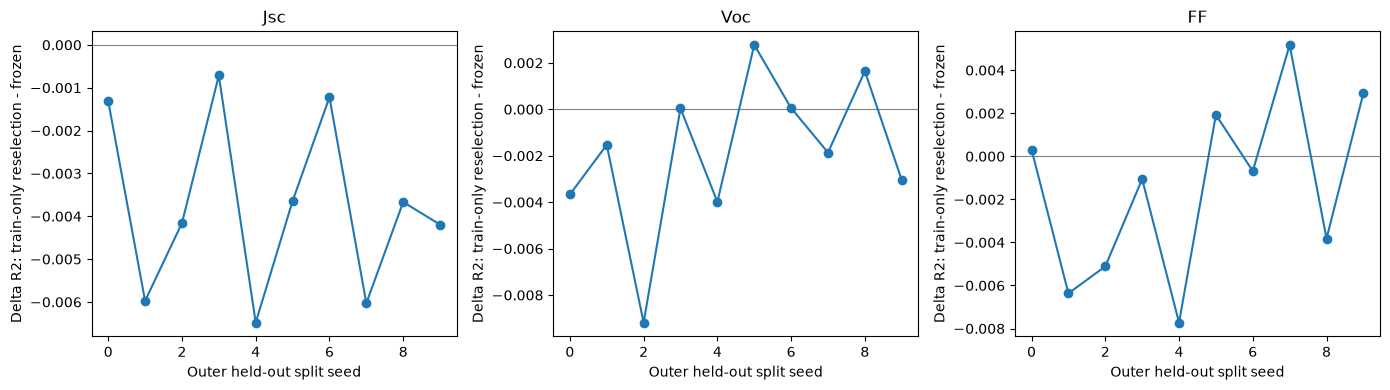

In [13]:

# ============================================================
# 12. Train-only reselection audit summary
# ============================================================

if RUN_TRAIN_ONLY_RESELECTION_AUDIT:
    TRAIN_ONLY_RESELECTION_SUMMARY = (
        TRAIN_ONLY_RESELECTION_RESULTS
        .groupby("target", as_index=False)
        .agg(
            n_splits=("split_seed", "nunique"),
            candidate_pool_size=("candidate_pool_size", "first"),
            selected_k=("selected_k", "first"),
            TrainOnly_R2_mean=("TrainOnly_R2", "mean"),
            TrainOnly_R2_std=("TrainOnly_R2", "std"),
            Frozen_R2_mean=("Frozen_R2", "mean"),
            Frozen_R2_std=("Frozen_R2", "std"),
            Allin_R2_mean=("Allin_R2", "mean"),
            Allin_R2_std=("Allin_R2", "std"),
            Delta_R2_TrainOnly_minus_Frozen_mean=(
                "Delta_R2_TrainOnly_minus_Frozen", "mean"
            ),
            Delta_R2_TrainOnly_minus_Frozen_std=(
                "Delta_R2_TrainOnly_minus_Frozen", "std"
            ),
            Delta_R2_TrainOnly_minus_Allin_mean=(
                "Delta_R2_TrainOnly_minus_Allin", "mean"
            ),
            Delta_R2_TrainOnly_minus_Allin_std=(
                "Delta_R2_TrainOnly_minus_Allin", "std"
            ),
            TrainOnly_RMSE_mean=("TrainOnly_RMSE", "mean"),
            TrainOnly_RMSE_std=("TrainOnly_RMSE", "std"),
            Frozen_RMSE_mean=("Frozen_RMSE", "mean"),
            Frozen_RMSE_std=("Frozen_RMSE", "std"),
            Allin_RMSE_mean=("Allin_RMSE", "mean"),
            Allin_RMSE_std=("Allin_RMSE", "std"),
            overlap_mean=("overlap_with_frozen", "mean"),
            overlap_min=("overlap_with_frozen", "min"),
            overlap_max=("overlap_with_frozen", "max"),
            jaccard_mean=("jaccard_with_frozen", "mean"),
        )
        .sort_values("target")
        .reset_index(drop=True)
    )

    display(TRAIN_ONLY_RESELECTION_SUMMARY.round(4))
    TRAIN_ONLY_RESELECTION_SUMMARY.to_csv(
        RESELECTION_OUTPUT_DIR / "train_only_reselection_summary.csv",
        index=False,
    )

    # Paired per-seed change relative to the original full-cohort frozen list.
    target_order = ["Jsc", "Voc", "FF"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, target_name in zip(axes, target_order):
        target_data = (
            TRAIN_ONLY_RESELECTION_RESULTS.loc[
                TRAIN_ONLY_RESELECTION_RESULTS["target"] == target_name
            ]
            .sort_values("split_seed")
        )
        ax.axhline(0, color="grey", linewidth=0.8)
        ax.plot(
            target_data["split_seed"],
            target_data["Delta_R2_TrainOnly_minus_Frozen"],
            marker="o",
        )
        ax.set_title(target_name)
        ax.set_xlabel("Outer held-out split seed")
        ax.set_ylabel("Delta R2: train-only reselection - frozen")

    fig.tight_layout()
    fig.savefig(
        RESELECTION_OUTPUT_DIR / "train_only_minus_frozen_delta_r2.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


In [14]:
# ============================================================
# 13. Per-feature selection stability across train-only reselection splits
# ============================================================

if "TRAIN_ONLY_RESELECTION_FEATURES" not in globals():
    raise RuntimeError(
        "Run Section 11 (train-only reselection audit) before this cell."
    )

N_AUDIT_SPLITS = TRAIN_ONLY_RESELECTION_RESULTS["split_seed"].nunique()

feature_stability_frames = []

for target_name in ["Jsc", "Voc", "FF"]:
    frozen_list = SELECTED_FEATURES[target_name]

    target_selections = TRAIN_ONLY_RESELECTION_FEATURES.loc[
        TRAIN_ONLY_RESELECTION_FEATURES["target"] == target_name
    ]

    counts = (
        target_selections
        .groupby("feature", as_index=False)
        .agg(
            times_selected=("split_seed", "nunique"),
            mean_rank_when_selected=("rank", "mean"),
        )
    )

    # Make sure every frozen-list feature appears here even if it was never
    # re-selected in any train-only split (times_selected = 0 in that case).
    all_features = sorted(set(counts["feature"]).union(frozen_list))
    counts = (
        counts.set_index("feature")
        .reindex(all_features)
        .rename_axis("feature")
        .reset_index()
    )
    counts["times_selected"] = counts["times_selected"].fillna(0).astype(int)

    counts["target"] = target_name
    counts["n_splits"] = N_AUDIT_SPLITS
    counts["selection_frequency"] = counts["times_selected"] / N_AUDIT_SPLITS
    counts["in_frozen_list"] = counts["feature"].isin(set(frozen_list))

    counts = counts.sort_values(
        ["selection_frequency", "feature"],
        ascending=[False, True],
    ).reset_index(drop=True)

    feature_stability_frames.append(counts)

FEATURE_STABILITY = pd.concat(feature_stability_frames, ignore_index=True)
FEATURE_STABILITY = FEATURE_STABILITY[
    ["target", "feature", "times_selected", "n_splits", "selection_frequency",
     "mean_rank_when_selected", "in_frozen_list"]
]
FEATURE_STABILITY.to_csv(
    RESELECTION_OUTPUT_DIR / "feature_selection_stability.csv",
    index=False,
)

for target_name in ["Jsc", "Voc", "FF"]:
    print(
        f"\n{'=' * 72}\n{target_name}: frozen-list features, selection frequency "
        f"across {N_AUDIT_SPLITS} train-only splits\n{'=' * 72}"
    )
    display(
        FEATURE_STABILITY.loc[
            (FEATURE_STABILITY["target"] == target_name)
            & (FEATURE_STABILITY["in_frozen_list"])
        ]
        .reset_index(drop=True)
        .round(3)
    )

# How stable is the frozen (whole-dataset) list specifically?
stability_summary_rows = []
for target_name in ["Jsc", "Voc", "FF"]:
    sub = FEATURE_STABILITY.loc[
        (FEATURE_STABILITY["target"] == target_name)
        & (FEATURE_STABILITY["in_frozen_list"])
    ]
    always_selected = int((sub["times_selected"] == N_AUDIT_SPLITS).sum())
    stability_summary_rows.append({
        "target": target_name,
        "frozen_list_size": len(sub),
        "n_splits": N_AUDIT_SPLITS,
        "always_selected_in_every_split": always_selected,
        "always_selected_fraction": (
            always_selected / len(sub) if len(sub) else np.nan
        ),
        "mean_selection_frequency": sub["selection_frequency"].mean(),
        "min_selection_frequency": sub["selection_frequency"].min(),
    })

FEATURE_STABILITY_SUMMARY = pd.DataFrame(stability_summary_rows)
display(FEATURE_STABILITY_SUMMARY.round(3))
FEATURE_STABILITY_SUMMARY.to_csv(
    RESELECTION_OUTPUT_DIR / "feature_selection_stability_summary.csv",
    index=False,
)

print(
    "\nInterpretation: 'always_selected_fraction' close to 1.0 means the frozen "
    "whole-dataset feature list is recovered essentially every time even when "
    "ranking only ever sees 80% of the data -- strong evidence the frozen "
    "representation is not an artifact of full-cohort ranking. Features with "
    "low selection_frequency are the ones most worth naming individually as a "
    "caveat in the thesis interpretation section, rather than treating the "
    "whole list as uniformly solid."
)



Jsc: frozen-list features, selection frequency across 10 train-only splits


,target,feature,times_selected,n_splits,selection_frequency,mean_rank_when_selected,in_frozen_list
0,Jsc,Absorber_to_ETL_ratio,10,10,1.0,2.100,True
1,Jsc,BC_thickness_clean,10,10,1.0,13.300,True
2,Jsc,ETL_thickness_clean,10,10,1.0,14.300,True
3,Jsc,HTL_thickness_clean,10,10,1.0,5.300,True
4,Jsc,PVK_thickness_clean,10,10,1.0,2.900,True
5,Jsc,backcontact.stack_sequence,10,10,1.0,11.300,True
6,Jsc,cell.area_measured,10,10,1.0,11.500,True
7,Jsc,etl.deposition_procedure,10,10,1.0,6.900,True
8,Jsc,etl.stack_sequence,10,10,1.0,10.100,True
9,Jsc,htl.deposition_procedure,10,10,1.0,17.200,True



Voc: frozen-list features, selection frequency across 10 train-only splits


,target,feature,times_selected,n_splits,selection_frequency,mean_rank_when_selected,in_frozen_list
0,Voc,Absorber_to_ETL_ratio,10,10,1.0,2.700,True
1,Voc,BC_thickness_clean,10,10,1.0,6.200,True
2,Voc,ETL_thickness_clean,10,10,1.0,14.700,True
3,Voc,HTL_thickness_clean,10,10,1.0,12.000,True
4,Voc,PVK_thickness_clean,10,10,1.0,12.400,True
5,Voc,cell.area_measured,10,10,1.0,13.900,True
6,Voc,etl.stack_sequence,10,10,1.0,10.700,True
7,Voc,htl.stack_sequence,10,10,1.0,1.200,True
8,Voc,perovskite.composition_a_ions,10,10,1.0,12.800,True
9,Voc,perovskite.composition_b_ions,10,10,1.0,2.100,True



FF: frozen-list features, selection frequency across 10 train-only splits


,target,feature,times_selected,n_splits,selection_frequency,mean_rank_when_selected,in_frozen_list
0,FF,Absorber_to_ETL_ratio,10,10,1.0,6.000,True
1,FF,ETL_n_layers,10,10,1.0,13.400,True
2,FF,ETL_thickness_clean,10,10,1.0,3.400,True
3,FF,PVK_thickness_clean,10,10,1.0,3.700,True
4,FF,backcontact.stack_sequence,10,10,1.0,21.400,True
5,FF,cell.area_measured,10,10,1.0,9.700,True
6,FF,cell.stack_sequence,10,10,1.0,13.000,True
7,FF,eqe.measured,10,10,1.0,6.500,True
8,FF,etl.stack_sequence,10,10,1.0,11.500,True
9,FF,ff_PVK_fraction_of_total_stack,10,10,1.0,1.000,True


,target,frozen_list_size,n_splits,always_selected_in_every_split,always_selected_fraction,mean_selection_frequency,min_selection_frequency
0,Jsc,20,10,15,0.750,0.915,0.3
1,Voc,20,10,16,0.800,0.955,0.6
2,FF,30,10,19,0.633,0.920,0.3



Interpretation: 'always_selected_fraction' close to 1.0 means the frozen whole-dataset feature list is recovered essentially every time even when ranking only ever sees 80% of the data -- strong evidence the frozen representation is not an artifact of full-cohort ranking. Features with low selection_frequency are the ones most worth naming individually as a caveat in the thesis interpretation section, rather than treating the whole list as uniformly solid.
